<a href="https://colab.research.google.com/github/Cosider24/machine-learning-fundamentals/blob/main/%D0%9E%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BF%D0%BE%D0%BB%D0%BD%D0%BE%D1%81%D0%B2%D1%8F%D0%B7%D0%BD%D0%BE%D0%B9_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D0%BE%D0%B9_%D1%81%D0%B5%D1%82%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Необходимо создать и обучить нейросеть распознавать рукописные цифры.

В качестве набора данных предполагается использовать [MNIST](https://ru.wikipedia.org/wiki/MNIST_(%D0%B1%D0%B0%D0%B7%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85)) копия которого находится в библиотеке [keras](https://keras.io/api/datasets/mnist/)

В процессе практики необходимо загрузить набор данных, преобразовать входной набор в формат, подходящий для обучения нейронной сети (преобразовать картинку в вектор-столбец и выполнить нормализацию данных), подобрать подходящую архитектуру с учетом использования полносвязных слоев, произвести обучение и проверку

Задача: по изображению определить, какая цифра на нем изображена.

In [ ]:
# загрузка датасета MNIST

from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

Здесь загружается набор данных MNIST, который уже встроен в библиотеку keras. Данные разделены на две части: обучающую выборку (x_train, y_train) и тестовую (x_test, y_test). Обучающая выборка используется для обучения модели, а тестовая — для проверки качества работы после обучения.

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical


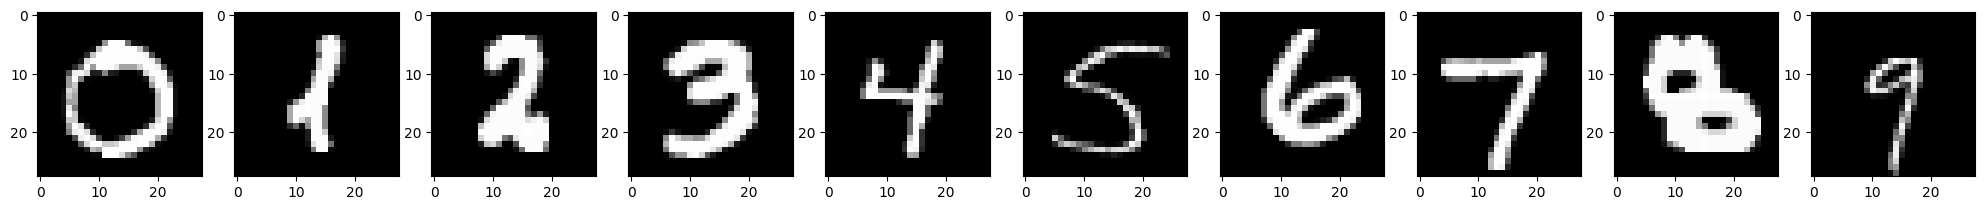

In [ ]:
# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt
# Подключение класса для работы с изображением
from PIL import Image
# Подключение библиотеки для генерации случайных чисел
import random
# Подключение библиотеки для работы с массивами
import numpy as np
# вывод изображений каждого класса для ознакомления с датасетом
fig, axs = plt.subplots(1, 10, figsize=(25,3)) # создаем полотно для 10 графиков с размером 25 на 3
for i in range(10):
  label_indexes = np.where(y_train == i)[0] # получаем список из индексов положений класса i в y_train
  index = random.choice(label_indexes) # выбирает случайный индекс из списка созданного выше
  img = x_train[index] # выбираем из x_train нужное положение
  axs[i].imshow(Image.fromarray(img), cmap='gray') # выводим изображение

plt.show()

Перед обучением важно понять, как выглядят данные. На этом шаге выводятся изображения каждой цифры от 0 до 9. Это помогает убедиться, что данные загружены корректно, и визуально оценить качество изображений. Также это даёт представление о задаче, которую предстоит решить нейросети.

Шаг 4. Подготовка данных

Задание: подготовьте данные для нейросети.

Что нужно сделать:
Преобразовать изображения 28×28 → в вектор длины 784
Нормализовать значения пикселей

Подсказка: делите на 255

In [ ]:
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


Шаг 5: создайте полносвязную нейронную сеть.

Требования:

вход: 784
минимум 2 скрытых слоя
выход: 10 классов

Подсказка: используйте relu и softmax

Sequential позволяет выстраивать слои последовательно. Сеть состоит из входного слоя (784 признака), двух скрытых полносвязных слоёв (Dense) и выходного слоя из 10 нейронов — по числу классов.

In [ ]:
model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Шаг 6. Компиляция модели

Задание: настройте процесс обучения.

Подсказка:

оптимизатор: adam
функция потерь: sparse_categorical_crossentropy

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Шаг 7. Обучение модели

Задание: обучите модель.

Подсказка:

epochs: 10
batch_size: 128
validation_split: 0.2

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8980 - loss: 0.3694 - val_accuracy: 0.9474 - val_loss: 0.1900
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9561 - loss: 0.1493 - val_accuracy: 0.9597 - val_loss: 0.1441
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9690 - loss: 0.1056 - val_accuracy: 0.9643 - val_loss: 0.1161
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9761 - loss: 0.0816 - val_accuracy: 0.9662 - val_loss: 0.1168
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9803 - loss: 0.0654 - val_accuracy: 0.9688 - val_loss: 0.1035
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9842 - loss: 0.0524 - val_accuracy: 0.9693 - val_loss: 0.1040
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9879 - loss: 0.0412 - val_accuracy: 0.9706 - val_loss: 0.1029
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9894 - loss: 0.0349 - val_accuracy: 0.

Шаг 8. Оценка модели

Задание: проверьте качество модели на тестовой выборке.

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Потери на тестовой выборке: {test_loss:.4f}")
print(f"Точность на тестовой выборке: {test_acc:.4f}")
print(f"Точность: {test_acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9755 - loss: 0.0836
Потери на тестовой выборке: 0.0836
Точность на тестовой выборке: 0.9755
Точность: 97.55%


Шаг 9. Анализ обучения

Задание: постройте графики обучения.

Подсказка: используйте history.history

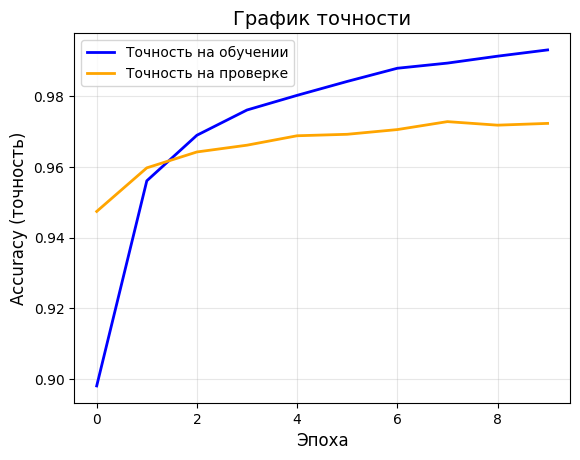

In [ ]:
plt.plot(history.history['accuracy'], label='Точность на обучении', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Точность на проверке', color='orange', linewidth=2)
plt.title('График точности', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Accuracy (точность)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

Шаг 10. Предсказание

Задание: проверьте работу модели на примерах.

Подсказка:

используйте model.predict
np.argmax для выбора класса

In [ ]:
x_sample = x_test[:10]
y_true = y_test[:10]
predictions = model.predict(x_sample)
predicted_classes = np.argmax(predictions, axis=1)
for i in range(10):
    print(f"Пример {i+1}: Истинная цифра = {y_true[i]}, Предсказание = {predicted_classes[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Пример 1: Истинная цифра = 7, Предсказание = 7
Пример 2: Истинная цифра = 2, Предсказание = 2
Пример 3: Истинная цифра = 1, Предсказание = 1
Пример 4: Истинная цифра = 0, Предсказание = 0
Пример 5: Истинная цифра = 4, Предсказание = 4
Пример 6: Истинная цифра = 1, Предсказание = 1
Пример 7: Истинная цифра = 4, Предсказание = 4
Пример 8: Истинная цифра = 9, Предсказание = 9
Пример 9: Истинная цифра = 5, Предсказание = 6
Пример 10: Истинная цифра = 9, Предсказание = 9


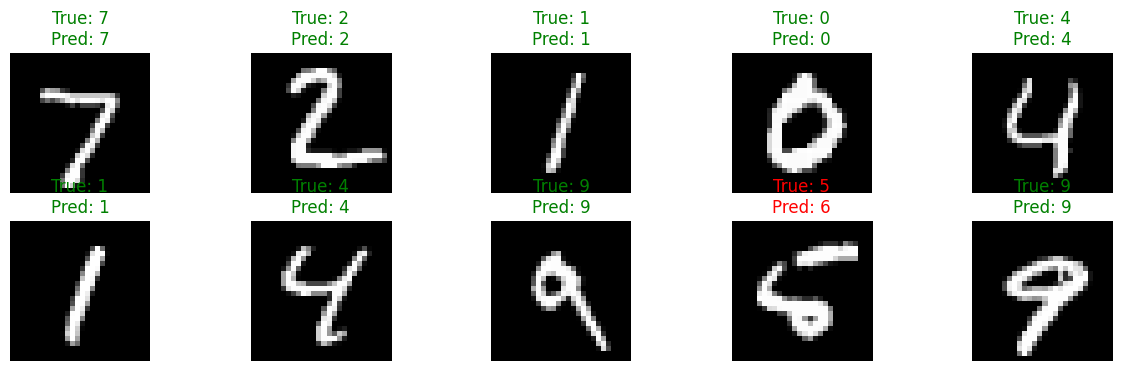

In [ ]:
plt.figure(figsize=(15, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    if predicted_classes[i] == y_true[i]:
        color = 'green'
    else:
        color = 'red'

    plt.title(f"True: {y_true[i]}\nPred: {predicted_classes[i]}", color=color)
    plt.axis('off')

plt.show()

Вопросы:

**Почему изображения нужно преобразовывать в вектор?**

Полносвязная нейронная сеть принимает на вход одномерный вектор признаков, а не двумерное изображение. Каждый пиксель становится отдельным входным признаком.

**Зачем нужна нормализация данных?**

Чтобы привести все значения пикселей к одному диапазону (0-1). Это ускоряет сходимость модели и улучшает качество обучения, так как градиент обновляется равномерно для всех признаков.

**Почему на выходном слое используется softmax?**

Softmax преобразует выходные значения в вероятности (сумма = 1), что позволяет интерпретировать результаты как уверенность модели в принадлежности к каждому классу.

**Чем отличается компиляция модели от обучения модели?**

Компиляция - это настройка параметров обучения (оптимизатор, функция потерь), она не обучает модель. Обучение - это процесс подбора весов на основе данных.

**Что показывает график функции потерь?**

Показывает, насколько сильно ошибки модели на обучающей и валидационной выборках уменьшаются с каждой эпохой. Падение графика означает, что модель учится.

